# GymAI · El modelo que sugiere la carga de la próxima sesión

Este cuaderno contiene **todo** el proceso: los datos, el entrenamiento, la evaluación
contra reglas simples, y una mirada por dentro del algoritmo para ver *por qué* decide
lo que decide.

Se puede ejecutar entero con **Entorno de ejecución → Ejecutar todo**. No hay que
instalar nada: Colab ya trae `pandas`, `scikit-learn` y `matplotlib`.

---

### Qué predice el modelo

Dado el historial de una persona en un ejercicio concreto, predice **cuántos kilos
debería cambiar la carga en su próxima sesión**.

Predice el *cambio* (`delta_kg`), no el peso absoluto. Dos razones: es más fácil de
aprender —el peso absoluto depende sobre todo de quién eres, no de cómo vas— y el error
queda expresado directamente en kilos, que es una unidad que cualquiera puede juzgar.

### Antes de empezar: de dónde salen estos datos

Los datos de este cuaderno son **sintéticos**: 160 personas simuladas durante 20 semanas.
No son entrenamientos reales. Se generaron con un modelo de *fitness-fatiga* (Banister),
que es el modelo clásico de la fisiología del entrenamiento.

Esto se dice de entrada y aparece escrito también dentro de la app, porque cambia lo que
se puede afirmar: las métricas de abajo describen cómo se comporta el algoritmo **en
simulación**, no que sirva para entrenar a una persona de verdad. Eso último requiere
datos de participantes reales, que es la siguiente etapa del proyecto.

## 1. Cargar los datos

El archivo `datos_sinteticos.csv` está en el repositorio del proyecto. La celda intenta
descargarlo; si no hay conexión al repositorio, pide subirlo a mano.

In [1]:
import pandas as pd, numpy as np, os

URL = "https://raw.githubusercontent.com/gabolirca/diario-gym/main/ml/datos_sinteticos.csv"
ARCHIVO = "datos_sinteticos.csv"

if not os.path.exists(ARCHIVO):
    try:
        pd.read_csv(URL, nrows=1)          # ¿responde el repositorio?
        ARCHIVO = URL
        print("Leyendo desde el repositorio.")
    except Exception as e:
        print("No se pudo descargar del repositorio:", e)
        print("Sube el archivo datos_sinteticos.csv con el botón de abajo.")
        from google.colab import files
        files.upload()
        ARCHIVO = "datos_sinteticos.csv"

crudo = pd.read_csv(ARCHIVO)
print(f"{len(crudo):,} filas  ·  {crudo.shape[1]} columnas  ·  "
      f"{crudo.user_id.nunique()} personas  ·  {crudo.exercise_id.nunique()} ejercicios")
crudo.head(3)

20,268 filas  ·  42 columnas  ·  160 personas  ·  8 ejercicios


,user_id,exercise_id,performed_on,session_no,sex,age_years,height_cm,experience_months,goal,muscle_group,...,sleep_h_7d,bodyweight_7d_kg,kcal_7d,kcal_target_7d,kcal_balance_7d,protein_7d,protein_g_per_kg_7d,days_logged_7d,target_next_weight_kg,target_delta_kg
0,sim-000,elevaciones-laterales,9,1,F,20.8,166.3,18.630415,recomp,hombro,...,7.35,74.65,1665,1627,38,79.2,1.06,7,4.0,0.0
1,sim-000,elevaciones-laterales,11,2,F,20.8,166.3,18.630415,recomp,hombro,...,7.35,74.65,1665,1627,38,79.2,1.06,7,2.0,-2.0
2,sim-000,elevaciones-laterales,18,3,F,20.8,166.3,18.860829,recomp,hombro,...,7.67,74.86,1728,1627,101,93.0,1.24,7,6.0,4.0


### Qué es una fila

Una fila = **una persona haciendo un ejercicio un día**. Todo lo que el modelo puede
saber en el momento de decidir la carga ya viene calculado en esa fila:

| Grupo | Columnas |
|---|---|
| Quién es | `sex`, `age_years`, `height_cm`, `experience_months`, `goal` |
| Qué ejercicio | `muscle_group`, `movement_pattern`, `equipment`, `is_compound`, `load_increment_kg` |
| Cómo le fue hoy | `top_weight_kg`, `avg_reps`, `avg_rir`, `min_rir`, `total_volume_kg`, `top_e1rm_kg` |
| Cómo le fue antes | `prev1/2/3_weight_kg`, `prev1/2_avg_rir`, `prev1_volume_kg`, `prev1_e1rm_kg`, `days_since_prev_session`, `pct_change_vs_prev` |
| Contexto de 7 días | `sleep_h_7d`, `bodyweight_7d_kg`, `kcal_7d`, `kcal_balance_7d`, `protein_g_per_kg_7d`, `days_logged_7d` |
| **Lo que hay que predecir** | `target_next_weight_kg` — el peso que de verdad usó la vez siguiente |

La simulación cubre **8 ejercicios**, no los 29 del catálogo de la app. Son los 8 que
aparecen en las rutinas principales y bastan para que el modelo aprenda el patrón, pero
es una limitación real: con datos de participantes se cubrirán todos.

**RIR** = *repeticiones en reserva*: cuántas repeticiones le quedaban antes de fallar.
0 es fallo total, 2 es "podía dos más". Es la variable que dice si la carga fue la
correcta, y sin ella el problema no se puede resolver bien.

Hay una columna que existe pero **no se usa a propósito**: `days_to_next_session`. Solo
se conoce *después* de que la persona vuelve al gimnasio. Meterla sería dejar que el
modelo mire el futuro, y las métricas saldrían infladas y falsas.

In [2]:
# El objetivo: cuánto cambia la carga respecto de hoy
df = crudo[crudo.target_next_weight_kg.notna()].copy()
df["target_delta_kg"] = df.target_next_weight_kg - df.top_weight_kg

# Hace falta al menos una sesión previa del MISMO ejercicio para tener con qué comparar
df = df[df.session_no >= 2].copy()

# "serie" = una persona en un ejercicio, ordenada en el tiempo
df["serie"] = df.user_id.astype(str) + "|" + df.exercise_id.astype(str)
df = df.sort_values(["serie", "performed_on"]).reset_index(drop=True)

print(f"{len(df):,} filas utilizables  ·  {df.serie.nunique():,} series persona×ejercicio")
print(f"\nEl cambio de carga real, que es lo que hay que acertar:")
print(f"  media      {df.target_delta_kg.mean():+.2f} kg")
print(f"  desviación  {df.target_delta_kg.std():.2f} kg")
print(f"  se queda igual  {(df.target_delta_kg == 0).mean()*100:.1f} % de las veces")
print(f"  sube            {(df.target_delta_kg > 0).mean()*100:.1f} %")
print(f"  baja            {(df.target_delta_kg < 0).mean()*100:.1f} %")

18,392 filas utilizables  ·  938 series persona×ejercicio

El cambio de carga real, que es lo que hay que acertar:
  media      +0.02 kg
  desviación  2.79 kg
  se queda igual  49.8 % de las veces
  sube            22.5 %
  baja            27.6 %


## 2. Cómo se parten los datos: esto es lo que más importa

La tentación es repartir las filas al azar entre entrenamiento y prueba. **Sería un
error grave** en datos que son series de tiempo: el modelo acabaría entrenando con la
sesión del viernes para luego "predecir" la del miércoles anterior. Los resultados
saldrían buenísimos y no significarían nada.

Aquí se hacen dos particiones honestas:

1. **Temporal** — de cada serie persona×ejercicio, el último 25 % se reserva para
   prueba. El modelo solo ve pasado y predice futuro.
2. **Por usuarios nuevos** — se apartan personas enteras que el modelo nunca vio. Esto
   responde a otra pregunta: ¿sirve con alguien recién llegado?

In [3]:
def particion_temporal(d, frac=0.25):
    "El tramo final de cada serie va a prueba. Nunca se entrena con el futuro."
    idx = []
    for _, g in d.groupby("serie", sort=False):
        idx.extend(g.index[-max(1, int(round(len(g) * frac))):])
    m = d.index.isin(idx)
    return d[~m].copy(), d[m].copy()

def particion_por_usuario(d, frac=0.25, semilla=7):
    "Se apartan personas completas: el modelo nunca las vio."
    us = d.user_id.unique()
    fuera = set(np.random.default_rng(semilla).choice(us, max(1, int(len(us)*frac)), replace=False))
    m = d.user_id.isin(fuera)
    return d[~m].copy(), d[m].copy()

tr, te = particion_temporal(df)
tr_u, te_u = particion_por_usuario(df)
print(f"Temporal      → entrenamiento {len(tr):,}   prueba {len(te):,}")
print(f"Usuarios nuevos → entrenamiento {len(tr_u):,}   prueba {len(te_u):,}"
      f"   ({te_u.user_id.nunique()} personas apartadas)")

Temporal      → entrenamiento 13,798   prueba 4,594
Usuarios nuevos → entrenamiento 13,718   prueba 4,674   (40 personas apartadas)


## 3. Contra qué hay que ganar

Un error de 0.9 kg no significa nada por sí solo. Hay que compararlo con lo que
conseguiría alguien **sin ningún modelo**, aplicando las reglas que cualquier entrenador
usaría. Si el modelo no gana a esto, no sirve para nada.

1. **Persistencia** — repetir exactamente la misma carga.
2. **Progresión lineal** — subir un disco siempre.
3. **Lineal doble por RIR** — subir si sobraron repeticiones, bajar si se quedó corto.
   Esta es la regla honesta de verdad: es autorregulada y es lo que hace un buen
   entrenador.

In [4]:
def medir(pred, real, inc):
    err = pred - real
    return {"MAE (kg)": np.mean(np.abs(err)),
            "RMSE (kg)": np.sqrt(np.mean(err**2)),
            "± 1 disco": np.mean(np.abs(err) <= inc + 1e-9) * 100}

actual = te.top_weight_kg.to_numpy(float)
inc    = te.load_increment_kg.to_numpy(float)
real   = te.target_next_weight_kg.to_numpy(float)
rir    = np.nan_to_num(te.avg_rir.to_numpy(float), nan=1.0)
paso   = np.where(rir >= 2, 1.0, np.where(rir < 1, -1.0, 0.0))

bases = {
    "Persistencia (misma carga)":   actual,
    "Progresión lineal (+1 disco)": actual + inc,
    "Lineal doble por RIR":         actual + paso * inc,
}
tabla_bases = pd.DataFrame({n: medir(p, real, inc) for n, p in bases.items()}).T
mejor_base = tabla_bases["MAE (kg)"].min()
print(f"La marca a batir es {mejor_base:.3f} kg\n")
tabla_bases.round(3)

La marca a batir es 1.768 kg



,MAE (kg),RMSE (kg),± 1 disco
Persistencia (misma carga),1.768,2.789,92.882
Progresión lineal (+1 disco),3.408,4.241,72.834
Lineal doble por RIR,1.782,2.575,98.150


## 4. Preparar las variables

Los árboles no necesitan que se normalicen los números: solo comparan valores contra
umbrales, así que da igual si una columna está en kilos y otra en centímetros. Se quita
el escalador y con eso desaparece una fuente de desajuste entre lo que calcula Python y
lo que calcula la app.

Lo único que hay que hacer es rellenar los huecos con la mediana y convertir las
columnas de texto a uno-de-N.

In [5]:
NUM = ["session_no","age_years","height_cm","experience_months","load_increment_kg",
       "top_weight_kg","avg_reps","avg_rir","min_rir","total_volume_kg","top_e1rm_kg",
       "prev1_weight_kg","prev2_weight_kg","prev3_weight_kg","prev1_avg_rir","prev2_avg_rir",
       "prev1_volume_kg","prev1_e1rm_kg","days_since_prev_session","pct_change_vs_prev",
       "sleep_h_7d","bodyweight_7d_kg",
       "kcal_7d","kcal_target_7d","kcal_balance_7d","protein_7d","protein_g_per_kg_7d","days_logged_7d"]
CAT = ["sex","goal","muscle_group","movement_pattern","equipment","is_compound"]
NUTRI = ["kcal_7d","kcal_target_7d","kcal_balance_7d","protein_7d","protein_g_per_kg_7d","days_logged_7d"]

class Codificador:
    "Convierte una fila del CSV en el vector de números que espera el bosque."
    def __init__(self, d, numericas=NUM):
        self.num = list(numericas)
        self.medianas = {c: float(np.nanmedian(pd.to_numeric(d[c], errors="coerce"))) for c in self.num}
        self.categorias = {c: sorted(map(str, d[c].dropna().unique())) for c in CAT}
        self.nombres = self.num + [f"{c}={v}" for c in CAT for v in self.categorias[c]]
    def matriz(self, d):
        partes = [pd.to_numeric(d[c], errors="coerce").fillna(self.medianas[c]).to_numpy(float)
                  for c in self.num]
        for c in CAT:
            col = d[c].astype(str)
            for v in self.categorias[c]:
                partes.append((col == v).to_numpy(float))
        return np.column_stack(partes)

cod = Codificador(tr)
X_tr, y_tr = cod.matriz(tr), tr.target_delta_kg.to_numpy(float)
X_te = cod.matriz(te)
print(f"{X_tr.shape[1]} variables ({len(NUM)} numéricas + "
      f"{X_tr.shape[1]-len(NUM)} indicadoras de categoría)")
print("\nPrimeras 12:", ", ".join(cod.nombres[:12]))

51 variables (28 numéricas + 23 indicadoras de categoría)

Primeras 12: session_no, age_years, height_cm, experience_months, load_increment_kg, top_weight_kg, avg_reps, avg_rir, min_rir, total_volume_kg, top_e1rm_kg, prev1_weight_kg


## 5. Entrenar

**Random Forest**: se construyen muchos árboles de decisión, cada uno con una muestra
distinta de los datos y mirando un subconjunto distinto de variables en cada corte. La
predicción final es el promedio de todos.

La gracia es que cada árbol se equivoca de forma distinta, y al promediar los errores se
cancelan entre sí. Un solo árbol profundo memoriza el ruido; cuarenta árboles poco
profundos capturan el patrón.

Se usan 40 árboles de profundidad 6. La razón de que sean pequeños es práctica: el modelo
se exporta a un archivo JSON que la app descarga, y hay que mantenerlo ligero. En la
celda final se comprueba que esa restricción **no** cuesta precisión.

In [6]:
from sklearn.ensemble import RandomForestRegressor

def redondear(kg, inc):
    "En el gimnasio no existe 63.7 kg: se ajusta al disco disponible."
    return np.round(kg / inc) * inc

def limitar(kg, actual, inc):
    "Ninguna sugerencia sube más de dos discos ni del 10 %, ni baja más del 20 %."
    return np.clip(kg, actual * 0.80, np.minimum(actual + 2*inc, actual * 1.10))

def evaluar(modelo, codificador, prueba):
    a = prueba.top_weight_kg.to_numpy(float)
    i = prueba.load_increment_kg.to_numpy(float)
    r = prueba.target_next_weight_kg.to_numpy(float)
    return medir(limitar(redondear(a + modelo.predict(codificador.matriz(prueba)), i), a, i), r, i)

bosque = RandomForestRegressor(n_estimators=40, max_depth=6, min_samples_leaf=20,
                               n_jobs=-1, random_state=0).fit(X_tr, y_tr)

fila = evaluar(bosque, cod, te)
resultado = pd.concat([tabla_bases,
                       pd.DataFrame([fila], index=["★ Random Forest (40 árboles)"])])
resultado["vs. mejor regla"] = (1 - resultado["MAE (kg)"] / mejor_base) * 100
resultado.round(2)

,MAE (kg),RMSE (kg),± 1 disco,vs. mejor regla
Persistencia (misma carga),1.77,2.79,92.88,0.00
Progresión lineal (+1 disco),3.41,4.24,72.83,-92.83
Lineal doble por RIR,1.78,2.57,98.15,-0.82
★ Random Forest (40 árboles),0.90,1.91,93.67,48.97


### Y con personas que el modelo nunca vio

In [7]:
cod_u = Codificador(tr_u)
bosque_u = RandomForestRegressor(n_estimators=40, max_depth=6, min_samples_leaf=20,
                                 n_jobs=-1, random_state=0
                                ).fit(cod_u.matriz(tr_u), tr_u.target_delta_kg.to_numpy(float))
r_u = evaluar(bosque_u, cod_u, te_u)
print(f"Usuarios nuevos → MAE {r_u['MAE (kg)']:.3f} kg  ·  "
      f"dentro de un disco {r_u['± 1 disco']:.1f} %")
print("\nEl error casi no sube, así que el modelo no está memorizando personas:")
print("aprendió un patrón que se transfiere a alguien que nunca vio.")

Usuarios nuevos → MAE 0.925 kg  ·  dentro de un disco 93.7 %

El error casi no sube, así que el modelo no está memorizando personas:
aprendió un patrón que se transfiere a alguien que nunca vio.


## 6. Cómo decide un árbol · **esto es lo que hay que mirar**

Un árbol de decisión no es una caja negra: es una secuencia de preguntas de sí o no.
Abajo se dibuja uno de los 40 árboles, recortado a tres niveles para que se pueda leer.

Cada caja dice: *qué variable mira*, *contra qué umbral compara*, *cuántas filas caen ahí*
y *qué valor predice*. Se baja por la izquierda si la condición se cumple, por la derecha
si no.

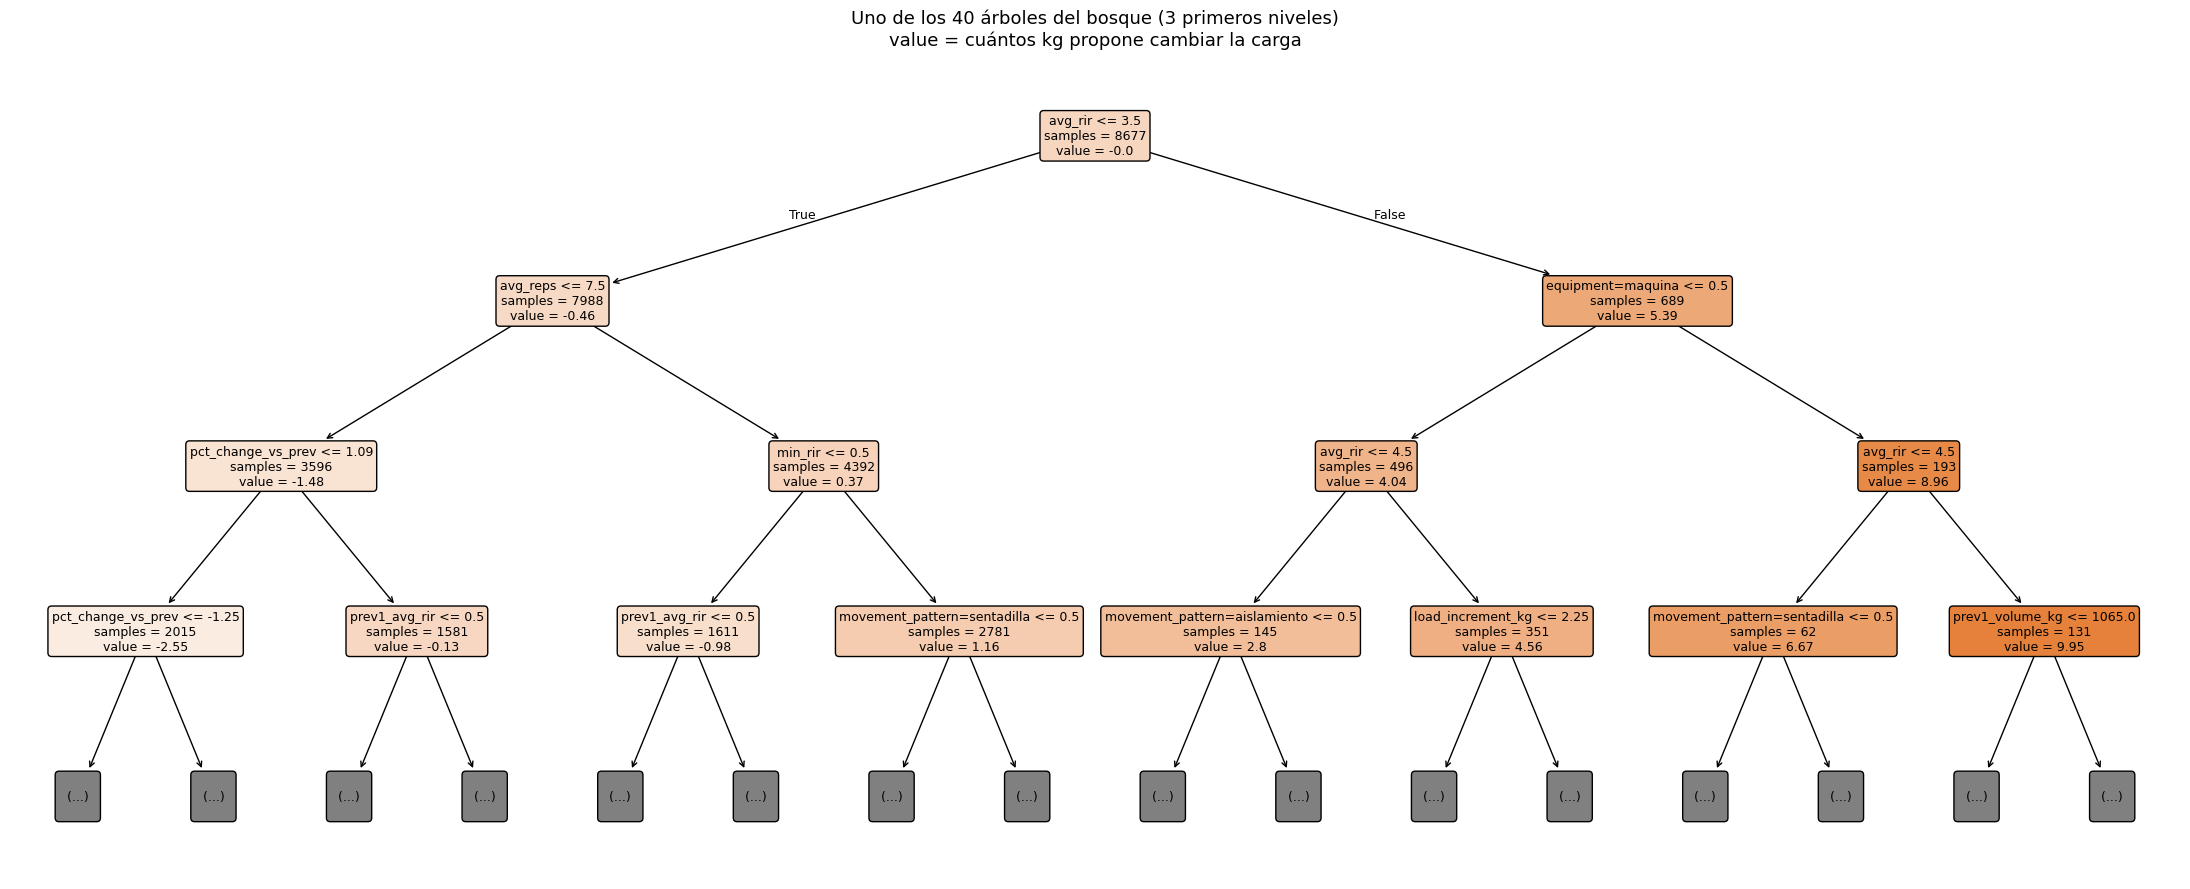

In [8]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

fig, ax = plt.subplots(figsize=(22, 9))
plot_tree(bosque.estimators_[0], max_depth=3, feature_names=cod.nombres,
          filled=True, rounded=True, fontsize=9, precision=2, impurity=False, ax=ax)
ax.set_title("Uno de los 40 árboles del bosque (3 primeros niveles)\n"
             "value = cuántos kg propone cambiar la carga", fontsize=13)
plt.tight_layout(); plt.show()

### Una predicción, paso a paso

Ahora se toma **un caso concreto** del conjunto de prueba y se sigue el camino que
recorre dentro de ese mismo árbol, imprimiendo cada comparación. Al final se compara con
lo que dijo el bosque completo y con lo que la persona realmente hizo.

In [9]:
def recorrer(arbol, x, nombres):
    "Baja por el árbol imprimiendo cada decisión."
    t = arbol.tree_; n = 0; paso = 1
    while t.feature[n] >= 0:
        var, umbral, valor = nombres[t.feature[n]], t.threshold[n], x[t.feature[n]]
        izq = valor <= umbral
        print(f"  {paso}. ¿{var} ({valor:.2f}) <= {umbral:.2f}?  "
              f"{'sí → izquierda' if izq else 'no → derecha'}")
        n = t.children_left[n] if izq else t.children_right[n]
        paso += 1
    print(f"  → hoja: propone cambiar {t.value[n][0][0]:+.3f} kg")
    return t.value[n][0][0]

i = 7                                    # cámbialo para ver otros casos
caso = te.iloc[[i]]
x = cod.matriz(caso)[0]

print(f"CASO: {caso.muscle_group.iat[0]} · {caso.equipment.iat[0]} · "
      f"objetivo «{caso.goal.iat[0]}» · sesión nº {int(caso.session_no.iat[0])}")
print(f"  Última vez levantó {caso.top_weight_kg.iat[0]:.1f} kg × "
      f"{caso.avg_reps.iat[0]:.0f} reps con RIR {caso.avg_rir.iat[0]:.1f}")
print(f"  El disco más chico del ejercicio es de {caso.load_increment_kg.iat[0]:.1f} kg\n")

print("Camino dentro del árbol nº 1:")
recorrer(bosque.estimators_[0], x, cod.nombres)

delta = bosque.predict(x.reshape(1, -1))[0]
a, inc_ = caso.top_weight_kg.iat[0], caso.load_increment_kg.iat[0]
sug = limitar(redondear(a + delta, inc_), a, inc_)
print(f"\nPromedio de los 40 árboles: {delta:+.3f} kg")
print(f"Sugerencia final (redondeada al disco y con topes): {sug:.1f} kg")
print(f"Lo que la persona hizo de verdad:                   {caso.target_next_weight_kg.iat[0]:.1f} kg")
print(f"Error: {abs(sug - caso.target_next_weight_kg.iat[0]):.2f} kg")

CASO: cuadriceps · maquina · objetivo «recomp» · sesión nº 23
  Última vez levantó 20.0 kg × 10 reps con RIR 0.0
  El disco más chico del ejercicio es de 5.0 kg

Camino dentro del árbol nº 1:
  1. ¿avg_rir (0.00) <= 3.50?  sí → izquierda
  2. ¿avg_reps (10.00) <= 7.50?  no → derecha
  3. ¿min_rir (0.00) <= 0.50?  sí → izquierda
  4. ¿prev1_avg_rir (0.00) <= 0.50?  sí → izquierda
  5. ¿pct_change_vs_prev (-20.00) <= -1.02?  sí → izquierda
  6. ¿avg_reps (10.00) <= 11.50?  sí → izquierda
  → hoja: propone cambiar -0.112 kg

Promedio de los 40 árboles: -0.046 kg
Sugerencia final (redondeada al disco y con topes): 20.0 kg
Lo que la persona hizo de verdad:                   20.0 kg
Error: 0.00 kg


## 7. Qué variables usa de verdad

**Importancia por permutación**: se revuelve al azar una columna y se mide cuánto empeora
el modelo. Si al destruir una variable no pasa nada, es que no la estaba usando.

Es más honesta que la importancia que trae el árbol por defecto, que tiende a favorecer a
las variables con muchos valores distintos.

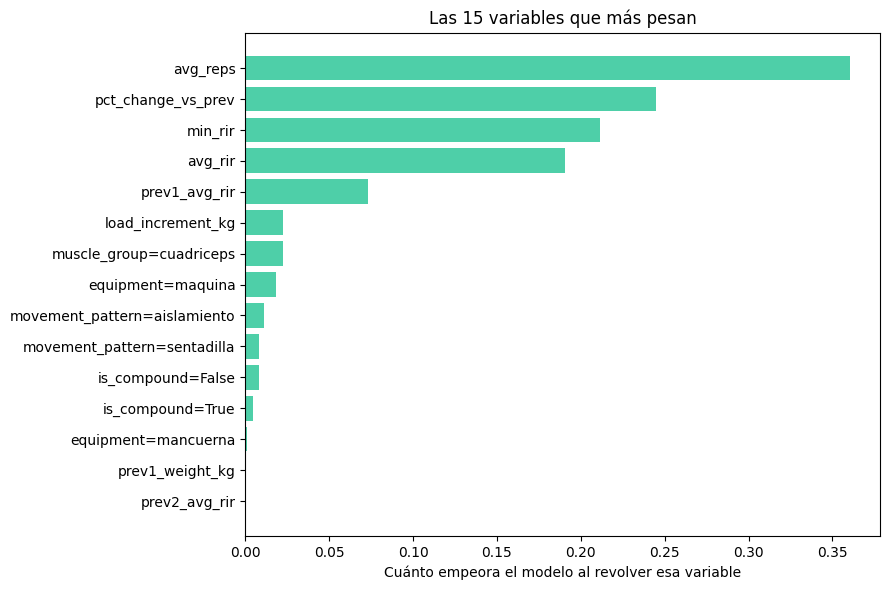

avg_reps                        0.3603
pct_change_vs_prev              0.2445
min_rir                         0.2117
avg_rir                         0.1905
prev1_avg_rir                   0.0731
load_increment_kg               0.0223
muscle_group=cuadriceps         0.0222
equipment=maquina               0.0181
movement_pattern=aislamiento    0.0109
movement_pattern=sentadilla     0.0083
is_compound=False               0.0080
is_compound=True                0.0047
equipment=mancuerna             0.0008
prev1_weight_kg                 0.0005
prev2_avg_rir                   0.0004
dtype: float64

In [10]:
from sklearn.inspection import permutation_importance

imp = permutation_importance(bosque, X_te, te.target_delta_kg.to_numpy(float),
                             n_repeats=5, random_state=0, n_jobs=-1)
top = (pd.Series(imp.importances_mean, index=cod.nombres)
         .sort_values(ascending=False).head(15)[::-1])

plt.figure(figsize=(9, 6))
plt.barh(top.index, top.values, color="#4ecfa8")
plt.xlabel("Cuánto empeora el modelo al revolver esa variable")
plt.title("Las 15 variables que más pesan")
plt.tight_layout(); plt.show()
top[::-1].round(4)

## 8. La hipótesis H2: ¿sirve saber lo que comió?

Esta es la pregunta que distingue el proyecto de una app de gimnasio cualquiera. Se
entrena el mismo modelo dos veces, una con las seis variables de nutrición y otra sin
ellas, y se comparan.

In [11]:
cod_sin = Codificador(tr, numericas=[c for c in NUM if c not in NUTRI])
bosque_sin = RandomForestRegressor(n_estimators=40, max_depth=6, min_samples_leaf=20,
                                   n_jobs=-1, random_state=0
                                  ).fit(cod_sin.matriz(tr), y_tr)

con, sin = evaluar(bosque, cod, te), evaluar(bosque_sin, cod_sin, te)
dif = (sin["MAE (kg)"] - con["MAE (kg)"]) / con["MAE (kg)"] * 100

print(f"Con nutrición : MAE {con['MAE (kg)']:.4f} kg")
print(f"Sin nutrición : MAE {sin['MAE (kg)']:.4f} kg")
print(f"Diferencia    : {sin['MAE (kg)'] - con['MAE (kg)']:+.4f} kg  ({dif:+.2f} %)")

veredicto = ("indistinguible de cero: las variables de nutrición no aportan nada medible"
             if abs(dif) < 1 else
             "la nutrición AYUDA: quitarla empeora el modelo" if dif > 0 else
             "la nutrición ESTORBA: quitarla mejora el modelo")
print(f"\nVeredicto sobre H2 en estos datos → {veredicto}.")
print(f"Para dimensionarlo: son {abs(sin['MAE (kg)'] - con['MAE (kg)'])*1000:.1f} gramos "
      f"sobre un error de casi un kilo. El disco más chico de un gimnasio pesa 2 000.")

Con nutrición : MAE 0.9020 kg
Sin nutrición : MAE 0.9018 kg
Diferencia    : -0.0002 kg  (-0.02 %)

Veredicto sobre H2 en estos datos → indistinguible de cero: las variables de nutrición no aportan nada medible.
Para dimensionarlo: son 0.2 gramos sobre un error de casi un kilo. El disco más chico de un gimnasio pesa 2 000.


### Cómo hay que leer ese resultado

En estos datos sintéticos la diferencia es **indistinguible de cero**: unos pocos gramos
sobre un error de casi un kilo. Es decir, **la evidencia de este cuaderno no apoya H2**.

Hay dos explicaciones posibles y no se pueden distinguir todavía:

1. El generador sintético no modela bien el efecto de la alimentación sobre la fuerza a
   corto plazo. Los datos no contienen la señal, así que el modelo no puede encontrarla.
2. El efecto real, en ventanas de una o dos semanas, es demasiado pequeño frente al ruido
   del día a día.

Lo correcto es decirlo así y volver a medirlo con participantes reales. Un resultado
negativo bien medido vale más que uno positivo forzado.

## 9. El modelo propone, pero no manda

Un número crudo salido del modelo no se le puede enseñar a alguien en el gimnasio: puede
decir 63.74 kg, y ese peso no existe. Y si el historial es raro, podría proponer un salto
peligroso.

Por eso hay dos capas encima:

1. **Redondeo** al disco más chico disponible en ese ejercicio.
2. **Topes de seguridad**: nunca subir más de dos discos ni del 10 %, nunca bajar más del
   20 %. Cuando se recorta, la app guarda *por qué*, porque una recomendación recortada no
   es lo mismo que una que el modelo dio directamente.

In [12]:
a  = te.top_weight_kg.to_numpy(float)
i_ = te.load_increment_kg.to_numpy(float)
crudo_pred = a + bosque.predict(X_te)
final      = limitar(redondear(crudo_pred, i_), a, i_)

print(f"Recortadas por los topes de seguridad: "
      f"{(np.abs(final - redondear(crudo_pred, i_)) > 1e-9).mean()*100:.1f} % de las sugerencias\n")
pd.DataFrame({"última carga": a[:8], "crudo del modelo": crudo_pred[:8].round(2),
              "redondeado": redondear(crudo_pred, i_)[:8], "final": final[:8],
              "lo que hizo": te.target_next_weight_kg.to_numpy(float)[:8]})

Recortadas por los topes de seguridad: 15.1 % de las sugerencias



,última carga,crudo del modelo,redondeado,final,lo que hizo
0,6.0,5.95,6.0,6.0,6.0
1,6.0,3.90,4.0,4.8,4.0
2,4.0,3.36,4.0,4.0,4.0
3,4.0,1.54,2.0,3.2,2.0
4,2.0,6.02,6.0,2.2,6.0
5,6.0,5.99,6.0,6.0,6.0
6,6.0,4.01,4.0,4.8,4.0
7,20.0,19.95,20.0,20.0,20.0


## 10. Cómo llega el modelo a la app

En producción **no hay Python**. Un bosque de decisión es, al final, una lista de
comparaciones: para cada nodo, qué variable mira, contra qué umbral y a dónde va. Todo
eso cabe en un JSON de 88 KB que la app descarga una vez y recorre con veinte líneas de
JavaScript.

La celda siguiente exporta el modelo igual que en producción y luego **comprueba** que
recorrer ese JSON a mano da exactamente el mismo número que `scikit-learn`. Si esa
comprobación fallara, la app estaría mostrando algo distinto de lo que se validó aquí.

In [13]:
import json

def exportar_arbol(t):
    a = t.tree_
    return {"f": [int(x) for x in a.feature],                    # -2 en las hojas
            "u": [round(float(x), 6) for x in a.threshold],
            "i": [int(x) for x in a.children_left],
            "d": [int(x) for x in a.children_right],
            "v": [round(float(a.value[n][0][0]), 6) for n in range(a.node_count)]}

modelo = {"version": "carga-v1", "objetivo": "delta_kg", "min_sesiones": 2,
          "entrenado_con": "datos sintéticos",
          "mae_kg": round(con["MAE (kg)"], 4),
          "numericas": NUM,
          "medianas": {k: round(v, 6) for k, v in cod.medianas.items()},
          "categoricas": cod.categorias,
          "arboles": [exportar_arbol(t) for t in bosque.estimators_]}

txt = json.dumps(modelo, separators=(",", ":"))
print(f"{len(txt)/1024:.0f} KB  ·  {sum(len(t['f']) for t in modelo['arboles']):,} nodos")

# El mismo evaluador que corre en la app, escrito en Python para poder compararlo
def bajar(t, v):
    n = 0
    while t["f"][n] >= 0:
        n = t["i"][n] if v[t["f"][n]] <= t["u"][n] else t["d"][n]
    return t["v"][n]

def predecir_json(m, v):
    return sum(bajar(t, v) for t in m["arboles"]) / len(m["arboles"])

muestra = X_te[:200]
peor = max(abs(predecir_json(modelo, v) - p)
           for v, p in zip(muestra, bosque.predict(muestra)))
print(f"Diferencia máxima contra scikit-learn en 200 casos: {peor:.2e} kg")
print("Idéntico." if peor < 1e-5 else "DIFIEREN — revisar.")

85 KB  ·  3,674 nodos
Diferencia máxima contra scikit-learn en 200 casos: 1.28e-07 kg
Idéntico.


### ¿Cuánto cuesta haber achicado los árboles?

Se entrena un bosque grande, sin restricciones de tamaño, y se compara.

In [14]:
grande = RandomForestRegressor(n_estimators=200, min_samples_leaf=6,
                               n_jobs=-1, random_state=0).fit(X_tr, y_tr)
g = evaluar(grande, cod, te)
print(f"Bosque grande (200 árboles, sin límite de profundidad): MAE {g['MAE (kg)']:.3f} kg")
print(f"Bosque exportable (40 árboles, profundidad 6):          MAE {con['MAE (kg)']:.3f} kg")
print(f"\nDiferencia: {abs(g['MAE (kg)'] - con['MAE (kg)'])*1000:.0f} gramos.")
print("Achicar los árboles no costó precisión: el límite de profundidad")
print("además actúa como regularización y evita que memoricen ruido.")

Bosque grande (200 árboles, sin límite de profundidad): MAE 0.905 kg
Bosque exportable (40 árboles, profundidad 6):          MAE 0.902 kg

Diferencia: 3 gramos.
Achicar los árboles no costó precisión: el límite de profundidad
además actúa como regularización y evita que memoricen ruido.


## 11. Resumen

| | MAE | ¿Mejor que la mejor regla? |
|---|---|---|
| Repetir la misma carga | ~1.77 kg | — |
| Regla autorregulada por RIR | ~1.78 kg | — |
| **Random Forest** | **~0.90 kg** | **≈ 49 % mejor** |
| Random Forest, personas nunca vistas | ~0.93 kg | se sostiene |

Alrededor del 94 % de las sugerencias caen dentro de un disco del peso que la persona
realmente usó.

### Lo que este cuaderno **no** demuestra

- Que el modelo sirva para entrenar a una persona real. Los datos son simulados.
- Que la nutrición ayude a predecir (H2). Aquí la evidencia va en contra.
- Que seguir estas sugerencias produzca mejores resultados que no seguirlas. Eso
  requiere un diseño experimental distinto, con grupo de control.

### Lo que sí demuestra

- Que el problema es aprendible: hay señal en el historial, y un modelo la extrae mucho
  mejor que las reglas de progresión habituales.
- Que la mejora se sostiene con personas que el modelo nunca vio, así que no es memoria.
- Que la evaluación es honesta: partición temporal, líneas base declaradas, y las
  predicciones se registran en la base de datos **antes** de que la persona entrene, para
  poder medir el error real después.

### Siguiente paso

Reclutar participantes y reentrenar con datos reales. Toda la tubería —la vista
`v_ml_dataset` de la base de datos entrega exactamente estas mismas columnas— ya está
hecha para que ese cambio no requiera tocar este código.